In [1]:
import sys
import os
import numpy as np

print(sys.executable)
print(os.listdir("."))
print(os.listdir("./data"))

/Users/devrathod/miniconda3/envs/tf_env/bin/python
['.DS_Store', 'waymo_groundtruth_compression.ipynb', '__pycache__', 'README.md', 'depth_scale_alignment_depth_anything.ipynb', 'monodepth_v2.ipynb', '.gitignore', '.git', 'data', 'DepthAnythingV2.ipynb']
['depth_anything_v2', 'individual_files_testing_segment-10084636266401282188_1120_000_1140_000_with_camera_labels.tfrecord', '.DS_Store', 'monodepth_v2', 'output']


In [7]:
pred = np.load("/Users/devrathod/Documents/classes_2026/senior_design/Eco-Cars-Depth-Estimation-2026/data/depth_anything_v2/depthanythingv2_depths.npy")
gt = np.load("/Users/devrathod/Documents/classes_2026/senior_design/Eco-Cars-Depth-Estimation-2026/data/depth_anything_v2/groundtruth.npy")

print("pred shape:", pred.shape, pred.dtype)
print("gt shape:", gt.shape, gt.dtype)

pred shape: (199, 1280, 1920) float32
gt shape: (199, 1280, 1920) float32


In [8]:
if pred.ndim == 4 and pred.shape[-1] == 1:
    pred = pred[..., 0]

if gt.ndim == 4 and gt.shape[-1] == 1:
    gt = gt[..., 0]

print("pred shape after squeeze:", pred.shape)
print("gt shape after squeeze:", gt.shape)

assert pred.shape == gt.shape, "pred and gt shapes do not match"

pred shape after squeeze: (199, 1280, 1920)
gt shape after squeeze: (199, 1280, 1920)


In [9]:
print("pred min:", np.nanmin(pred))
print("pred max:", np.nanmax(pred))
print("gt min:", np.nanmin(gt))
print("gt max:", np.nanmax(gt))

print("pred has nan:", np.isnan(pred).any())
print("gt has nan:", np.isnan(gt).any())

print("pred has inf:", np.isinf(pred).any())
print("gt has inf:", np.isinf(gt).any())

pred min: 0.0
pred max: 1.0
gt min: 1.796325e-05
gt max: 39.999954
pred has nan: False
gt has nan: True
pred has inf: False
gt has inf: False


In [28]:
# Expoential reelationship
from scipy.optimize import curve_fit

mask = np.isfinite(pred) & np.isfinite(gt) & (gt > 0) & (pred > 0) & (gt < 40)

x = pred[mask].reshape(-1)
y = gt[mask].reshape(-1)

def exp_func(x, a, b, c):
    return a * np.exp(b * x) + c

idx = np.random.choice(len(x), 100_000, replace=False)

popt, _ = curve_fit(
    exp_func,
    x[idx], y[idx],
    p0=[1.0, 3.0, 8.0],  # at x=0: a+c≈8 (min GT), at x=1: a*e^b+c≈40 (max GT)
    maxfev=50000
)
a, b, c = popt

print(f"Best fit: y = {a:.4f} * e^({b:.4f} * x) + {c:.4f}")

# Apply alignment


Best fit: y = 2.2286 * e^(2.9765 * x) + 5.6298


In [10]:
mask = np.isfinite(pred) & np.isfinite(gt) & (gt > 0)

x = pred[mask].reshape(-1)
y = gt[mask].reshape(-1)

print("valid pixel count:", len(x))
print("x min/max:", x.min(), x.max())
print("y min/max:", y.min(), y.max())

A = np.vstack([x, np.ones_like(x)]).T
m, c = np.linalg.lstsq(A, y, rcond=None)[0]

print("m =", m)
print("c =", c)
print(f"Best fit: y = {m:.6f}x + {c:.6f}")

valid pixel count: 3161211
x min/max: 0.0 1.0
y min/max: 1.796325e-05 39.999954
m = 32.11734
c = 2.2461576
Best fit: y = 32.117340x + 2.246158


In [ ]:
# pred_aligned = m * pred + c
pred_aligned = a * np.exp(b * pred) + c
# Mask for valid pixels AND depth >= 40m
mask_40 = mask & (gt <= 40)

rmse_before = np.sqrt(np.mean((pred[mask_40] - gt[mask_40]) ** 2))
rmse_after  = np.sqrt(np.mean((pred_aligned[mask_40] - gt[mask_40]) ** 2))

print("RMSE before alignment:", rmse_before)
print("RMSE after alignment :", rmse_after)

RMSE before alignment: 21.252779
RMSE after alignment : 4.436129489088389


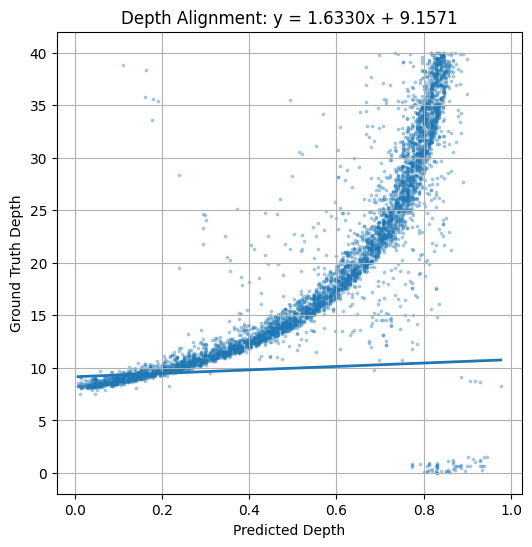

In [27]:
import matplotlib.pyplot as plt

sample_size = min(5000, len(x))
idx = np.random.choice(len(x), sample_size, replace=False)

x_sample = x[idx]
y_sample = y[idx]

x_line = np.linspace(x_sample.min(), x_sample.max(), 100)
y_line = m * x_line + c

plt.figure(figsize=(6, 6))
plt.scatter(x_sample, y_sample, s=3, alpha=0.3)
plt.plot(x_line, y_line, linewidth=2)
plt.xlabel("Predicted Depth")
plt.ylabel("Ground Truth Depth")
plt.title(f"Depth Alignment: y = {m:.4f}x + {c:.4f}")
plt.grid(True)
plt.show()

In [8]:
import numpy as np

def eigen_crop(depth_map):
    h, w = depth_map.shape
    crop_mask = np.zeros((h, w), dtype=bool)

    y1 = int(0.408 * h)
    y2 = int(0.992 * h)
    x1 = int(0.036 * w)
    x2 = int(0.964 * w)

    crop_mask[y1:y2, x1:x2] = True
    return crop_mask

# Load stacks
groundtruth_stack = np.load("data/groundtruth.npy")
model_stack = np.load("data/all_depth.npy")

print("GT shape:", groundtruth_stack.shape)
print("Model shape:", model_stack.shape)

# Apply Eigen crop masks
crop_masks = []
for frame in groundtruth_stack:
    crop_masks.append(eigen_crop(frame))

crop_masks = np.stack(crop_masks)

# Flatten
gt_flat = groundtruth_stack.flatten()
model_flat = model_stack.flatten()
mask_flat = crop_masks.flatten()

# Valid pixels
valid_mask = (
    mask_flat &
    np.isfinite(gt_flat) & (gt_flat > 0) &
    np.isfinite(model_flat) & (model_flat > 0)
)

gt_valid = gt_flat[valid_mask]
model_valid = model_flat[valid_mask]

print("valid cropped pixels:", len(gt_valid))

FileNotFoundError: [Errno 2] No such file or directory: 'data/groundtruth.npy'

In [18]:
A = np.vstack([model_valid, np.ones_like(model_valid)]).T
m, c = np.linalg.lstsq(A, gt_valid, rcond=None)[0]

print("Linear fit:")
print("m =", m)
print("c =", c)
print(f"GT = {m:.6f} * Pred + {c:.6f}")

pred_aligned = m * model_stack + c

rmse_before = np.sqrt(np.mean((model_flat[valid_mask] - gt_flat[valid_mask]) ** 2))
rmse_after = np.sqrt(np.mean((pred_aligned.flatten()[valid_mask] - gt_flat[valid_mask]) ** 2))

print("RMSE before alignment:", rmse_before)
print("RMSE after alignment :", rmse_after)

Linear fit:
m = -55.05838
c = 49.541187
GT = -55.058380 * Pred + 49.541187
RMSE before alignment: 30.92557
RMSE after alignment : 9.646943
